Mandel_analytical


Mandel 2D consolidation — parameters
  G    = 41666.7 Pa
  cv   = 0.011111 m^2/s  (Mandel coefficient)
  tc   = a^2/cv = 90.00 s
  p_u  = q*B*(1+nu_u)/3 = 500.0 Pa  (initial undrained pressure)
  A_eig = (1-nu)/(nu_u-nu) = 2.6667

First 5 eigenvalues xi_n: [ 1.28734215  4.63159966  7.80597844 10.96137659 14.11059742]
Normalisation check: p(0,0)/p_u = 0.995154  (converges to 1 as N->inf)

Mandel-Cryer peak at centre:
  t_peak/tc = 0.07155
  p_peak    = 553.45 Pa  (p_u = 500.0 Pa)
  p_peak/p_u = 1.1069  (>1 confirms Mandel-Cryer effect)

Rigid-plate settlement:
  u_y(b,0+)   = -1.5000 mm
  u_y(b,inf)  = -2.4000 mm
Saved mandel_analytical.png

Loaded MOOSE output: Mandel_2D.csv
  Columns : ['time', 'p_x0', 'p_x025', 'p_x050', 'p_x075', 'uy_top_corner']
  Rows    : 73
Saved mandel_comparison.png

  MOOSE: centre pressure peak = 550.03 Pa at t = 7.5 s  (t/tc = 0.083)
  Ratio p_peak/p_u = 1.1001  (>1 confirms Mandel-Cryer)

  MOOSE: final top displacement = -2.3660 mm
  Analytical final at s

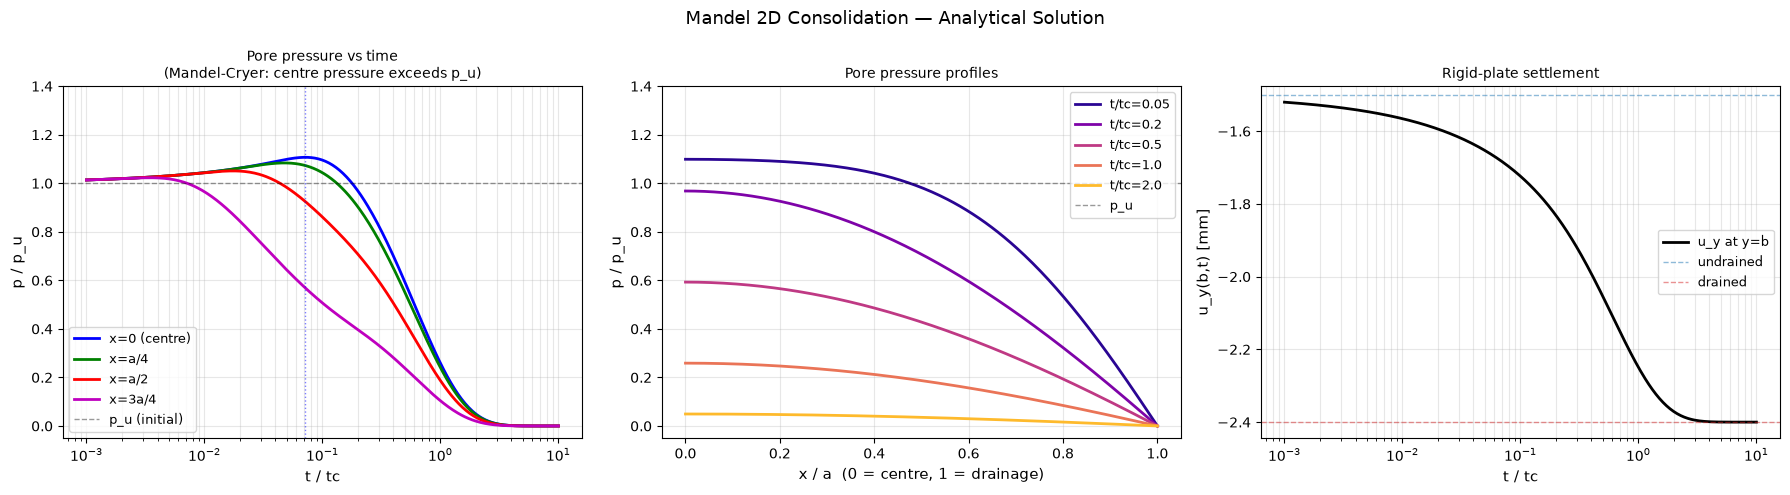

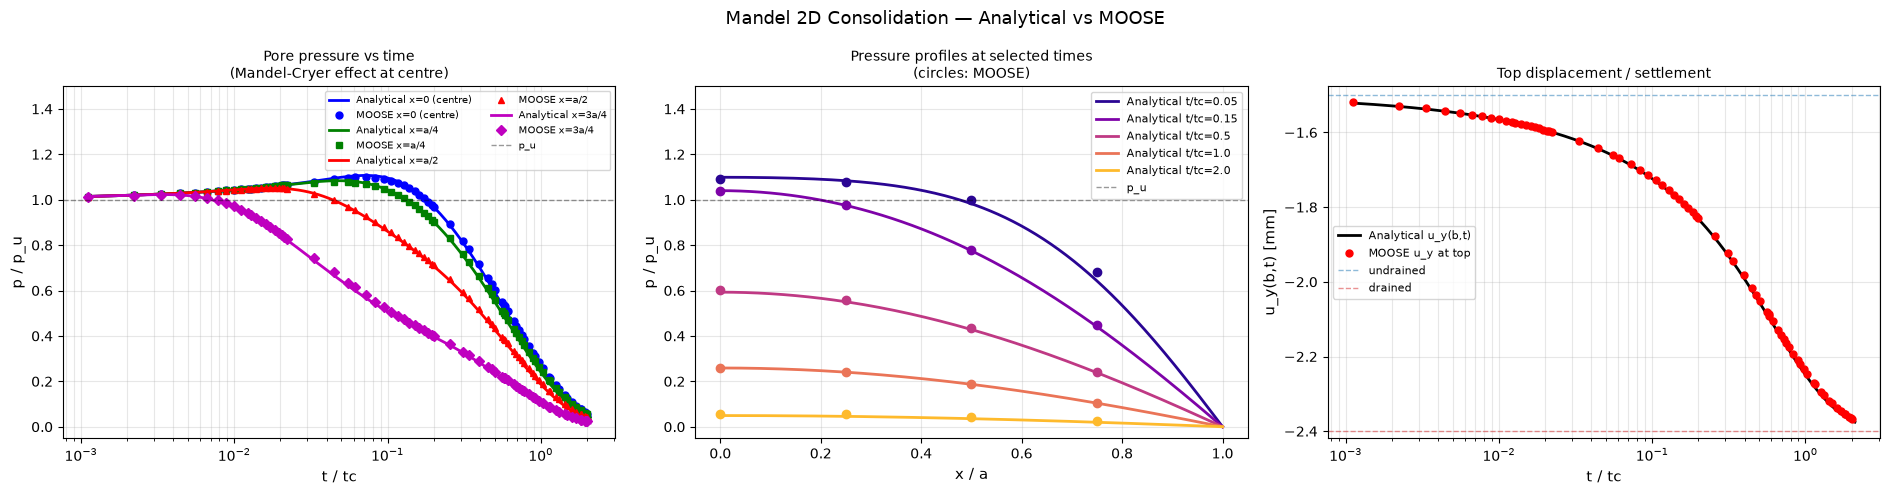

In [4]:
"""
Mandel 2D consolidation — analytical solution and MOOSE comparison.

Problem
-------
A rectangular poro-elastic sample (half-width a, half-height b) is compressed
by two rigid, smooth, impermeable plates at y = ±b.  The vertical faces at
x = ±a drain freely (p = 0) while the plates prevent drainage at y = ±b.

Exploiting double symmetry, only the quarter domain [0,a]×[0,b] is modelled
in Mandel_2D.i.

Key feature — Mandel-Cryer effect:
    After the load is applied the pore pressure at the centre (x = 0) first
    INCREASES above the initial undrained value before dissipating.
    This happens because the drained material near x = a stiffens and
    transfers load to the undrained core, raising its mean stress and hence
    its pore pressure.

Governing assumptions
---------------------
- Biot coefficient alpha = 1,  Skempton B = 1 (incompressible fluid+grains)
- Undrained Poisson ratio nu_u = 0.5
- Mandel consolidation coefficient:
      cv = 2*(k/mu)*B^2*G*(1 - nu)*(1 + nu_u)^2
           / (9*(1 - nu_u)*(nu_u - nu))
- Initial undrained pore pressure at the interior:
      p_u = q*B*(1 + nu_u)/3
  which reduces to p_u = q/2 for B=1 and nu_u=0.5.

Eigenvalue condition  [Mandel 1953; Abousleiman et al. 1996]:
      tan(xi_n) = ((1-nu)/(nu_u - nu)) * xi_n

Pore pressure series:
      p(x, t) = p_u * sum_n A_n * [cos(xi_n*x/a) - cos(xi_n)]
                * exp(-xi_n^2 * cv*t/a^2)
  where:
      A_n = 2*sin(xi_n) / (xi_n - sin(xi_n)*cos(xi_n))

The bracketed spatial term enforces the drained boundary p(x=a,t)=0.
At x=0 and t=0, the series converges to p_u as n->inf.

Vertical displacement under the rigid plate:
      u_y(y,t) = [-q*(1-nu)/(2G)
                  + q*(1-nu_u)/G * sum_n B_n * exp(-xi_n^2*cv*t/a^2)] * y
  where:
      B_n = sin(xi_n)*cos(xi_n) / (xi_n - sin(xi_n)*cos(xi_n))

At t=0+, u_y(b) = -q*(1-nu_u)*b/(2G); as t->inf,
u_y(b) = -q*(1-nu)*b/(2G).

References
----------
Mandel, J. (1953). Consolidation des sols (étude mathématique). Géotechnique, 3(7), 287-299.
Abousleiman, Y., Cheng, A.H.-D., Cui, L., Detournay, E., Roegiers, J.-C. (1996).
  Mandel's problem revisited. Géotechnique, 46(2), 187-195.
Detournay, E. & Cheng, A.H.-D. (1993). Fundamentals of Poroelasticity.
  In Comprehensive Rock Engineering, Vol. 2, Pergamon.

Usage
-----
Standalone analytical plots:
    python mandel_analytical.py

Comparison with MOOSE (after running Mandel_2D.i):
    python mandel_analytical.py Mandel_2D.csv
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import sys
from pathlib import Path


def _strip_jupyter_args(argv):
    """Remove IPython kernel flags that are injected into notebook sys.argv."""
    cleaned = []
    skip_next = False
    for arg in argv:
        if skip_next:
            skip_next = False
            continue

        if arg in ('-f', '--f', '--file'):
            skip_next = True
            continue
        if arg.startswith(('-f=', '--f=', '--file=', '--IPKernelApp.connection_file=')):
            continue
        if arg.endswith('.json') and Path(arg).name.startswith('kernel-'):
            continue

        cleaned.append(arg)
    return cleaned


def _csv_from_argv(argv, default='Mandel_2D.csv'):
    for arg in _strip_jupyter_args(argv):
        if arg.startswith('-'):
            continue
        return arg
    return default


def _resolve_csv_file(csv_file):
    path = Path(csv_file).expanduser()
    if path.exists() or path.is_absolute():
        return path

    candidates = []
    if '__file__' in globals():
        candidates.append(Path(__file__).resolve().parent / path)
    candidates.append(Path.cwd() / 'Examples' / 'HM' / 'Mandel' / path)

    for candidate in candidates:
        if candidate.exists():
            return candidate
    return path

# ============================================================
# Material parameters  — must match Mandel_2D.i
# ============================================================
E    = 1e5   # Young's modulus (Pa)
nu   = 0.2   # Drained Poisson's ratio
nu_u = 0.5   # Undrained Poisson's ratio (B=1, incompressible)
phi  = 0.3   # Initial porosity
k    = 1e-10 # Intrinsic permeability (m^2)
mu   = 1e-3  # Fluid viscosity (Pa·s)
alpha_biot = 1.0
B_sk = 1.0  # Skempton coefficient

# Derived constants
G   = E / (2.0 * (1.0 + nu))
K   = E / (3.0 * (1.0 - 2.0*nu))
lam = K - 2.0*G/3.0

# Mandel consolidation coefficient.  k/mu is hydraulic mobility.
cv = (2.0 * (k / mu) * B_sk**2 * G * (1.0 - nu) * (1.0 + nu_u)**2 /
      (9.0 * (1.0 - nu_u) * (nu_u - nu)))

# Geometry
a      = 1.0    # Half-width in x (drainage direction, m)
b      = 0.25   # Half-height in y (loading direction, m)
q_load = 1000.0 # Applied compressive stress (Pa)

# Characteristic time and undrained pressure
tc  = a**2 / cv
p_u = q_load * B_sk * (1.0 + nu_u) / 3.0  # Initial undrained pore pressure (Pa)

# Eigenvalue factor:  tan(xi) = A_eig * xi
A_eig = (1.0 - nu) / (nu_u - nu)

print("=" * 55)
print("Mandel 2D consolidation — parameters")
print(f"  G    = {G:.1f} Pa")
print(f"  cv   = {cv:.6f} m^2/s  (Mandel coefficient)")
print(f"  tc   = a^2/cv = {tc:.2f} s")
print(f"  p_u  = q*B*(1+nu_u)/3 = {p_u:.1f} Pa  (initial undrained pressure)")
print(f"  A_eig = (1-nu)/(nu_u-nu) = {A_eig:.4f}")
print("=" * 55)


# ============================================================
# Eigenvalue computation
# ============================================================
def _eig_func(xi):
    """f(xi) = tan(xi) - A_eig * xi.  Roots give Mandel eigenvalues."""
    return np.tan(xi) - A_eig * xi


def find_mandel_eigenvalues(n_roots=50):
    """
    Positive roots of  tan(xi) = A_eig * xi.

    Roots lie in  (n*pi, n*pi + pi/2)  for n = 0, 1, 2, ...
    (A_eig > 1 for nu < nu_u, so there is exactly one root per interval.)
    """
    roots = []
    eps   = 1e-10
    n     = 0
    while len(roots) < n_roots and n < 2000:
        lo = n * np.pi + eps
        hi = n * np.pi + np.pi / 2.0 - eps
        try:
            root = brentq(_eig_func, lo, hi, xtol=1e-14, maxiter=1000)
            if root > eps:
                roots.append(root)
        except ValueError:
            pass
        n += 1
    return np.array(roots)


xi_n = find_mandel_eigenvalues(n_roots=50)
print(f"\nFirst 5 eigenvalues xi_n: {xi_n[:5]}")

# Normalisation check at x=0 and t=0: the pressure series converges to p_u.
_norm = sum(2.0 * np.sin(x) * (1.0 - np.cos(x)) /
            (x - np.sin(x) * np.cos(x)) for x in xi_n)
print(f"Normalisation check: p(0,0)/p_u = {_norm:.6f}  (converges to 1 as N->inf)")


# ============================================================
# Pore pressure analytical formula
# ============================================================
def mandel_pressure(x, t, n_terms=None):
    """
    Mandel analytical pore pressure at position x (0 <= x <= a), time t >= 0.

    p(x, t) = p_u * sum_n A_n * [cos(xi_n*x/a) - cos(xi_n)]
              * exp(-xi_n^2 * cv * t / a^2)
    where  A_n = 2*sin(xi_n) / (xi_n - sin(xi_n)*cos(xi_n)).

    Returns p in Pa.
    """
    xn    = xi_n[:n_terms] if n_terms else xi_n
    x_arr = np.asarray(x, dtype=float)
    total = np.zeros_like(x_arr) if x_arr.ndim > 0 else 0.0
    for xi in xn:
        A_n        = 2.0 * np.sin(xi) / (xi - np.sin(xi) * np.cos(xi))
        shape      = np.cos(xi * x_arr / a) - np.cos(xi)
        time_decay = np.exp(-xi**2 * cv * t / a**2)
        total      = total + A_n * shape * time_decay
    return p_u * total


def mandel_vertical_displacement(y, t, n_terms=None):
    """
    Mandel analytical vertical displacement at height y, time t >= 0.

    Compression is negative. The top plate displacement is obtained with
    y=b. The formula is the rigid-plate settlement series used for Mandel's
    problem, with q_load = F/a in the Cheng-Detournay notation.
    """
    xn = xi_n[:n_terms] if n_terms else xi_n
    series = 0.0
    for xi in xn:
        B_n = np.sin(xi) * np.cos(xi) / (xi - np.sin(xi) * np.cos(xi))
        series += B_n * np.exp(-xi**2 * cv * t / a**2)

    strain_y = (-q_load * (1.0 - nu) / (2.0 * G) +
                q_load * (1.0 - nu_u) / G * series)
    return strain_y * np.asarray(y, dtype=float)


# ============================================================
# Analytical-only plots
# ============================================================
def plot_analytical():
    # Log time array to capture the Mandel-Cryer transient
    t_arr = np.logspace(-3, 1, 400) * tc

    p_x0   = np.array([mandel_pressure(0.0,     t) for t in t_arr])
    p_x025 = np.array([mandel_pressure(0.25*a,  t) for t in t_arr])
    p_x050 = np.array([mandel_pressure(0.50*a,  t) for t in t_arr])
    p_x075 = np.array([mandel_pressure(0.75*a,  t) for t in t_arr])
    uy_top = np.array([mandel_vertical_displacement(b, t) for t in t_arr])

    # Find the Mandel-Cryer peak
    i_peak  = np.argmax(p_x0)
    t_peak  = t_arr[i_peak]
    p_peak  = p_x0[i_peak]

    print(f"\nMandel-Cryer peak at centre:")
    print(f"  t_peak/tc = {t_peak/tc:.5f}")
    print(f"  p_peak    = {p_peak:.2f} Pa  (p_u = {p_u:.1f} Pa)")
    print(f"  p_peak/p_u = {p_peak/p_u:.4f}  (>1 confirms Mandel-Cryer effect)")
    print("\nRigid-plate settlement:")
    print(f"  u_y(b,0+)   = {-q_load*(1.0-nu_u)*b/(2.0*G)*1e3:.4f} mm")
    print(f"  u_y(b,inf)  = {-q_load*(1.0-nu)*b/(2.0*G)*1e3:.4f} mm")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Mandel 2D Consolidation — Analytical Solution', fontsize=13)

    # ── Left: p/p_u vs t/tc (Mandel-Cryer effect) ──
    ax = axes[0]
    ax.semilogx(t_arr / tc, p_x0   / p_u, 'b-',  lw=2, label='x=0 (centre)')
    ax.semilogx(t_arr / tc, p_x025 / p_u, 'g-',  lw=2, label='x=a/4')
    ax.semilogx(t_arr / tc, p_x050 / p_u, 'r-',  lw=2, label='x=a/2')
    ax.semilogx(t_arr / tc, p_x075 / p_u, 'm-',  lw=2, label='x=3a/4')
    ax.axhline(1.0, color='k', ls='--', lw=1, alpha=0.4, label='p_u (initial)')
    ax.axvline(t_peak / tc, color='b', ls=':', lw=1, alpha=0.5)
    ax.set_xlabel('t / tc', fontsize=11)
    ax.set_ylabel('p / p_u', fontsize=11)
    ax.set_title('Pore pressure vs time\n(Mandel-Cryer: centre pressure exceeds p_u)', fontsize=10)
    ax.set_ylim([-0.05, 1.4])
    ax.legend(fontsize=9)
    ax.grid(True, which='both', alpha=0.3)

    # ── Right: pore pressure profiles at several times ──
    ax    = axes[1]
    Tv_list = [0.05, 0.2, 0.5, 1.0, 2.0]
    clrs  = plt.cm.plasma(np.linspace(0.05, 0.85, len(Tv_list)))
    x_arr = np.linspace(0, a, 300)
    for Tv, c in zip(Tv_list, clrs):
        t     = Tv * tc
        p_prof = mandel_pressure(x_arr, t)
        ax.plot(x_arr / a, p_prof / p_u, color=c, lw=2, label=f't/tc={Tv}')
    ax.axhline(1.0, color='k', ls='--', lw=1, alpha=0.4, label='p_u')
    ax.set_xlabel('x / a  (0 = centre, 1 = drainage)', fontsize=11)
    ax.set_ylabel('p / p_u', fontsize=11)
    ax.set_title('Pore pressure profiles', fontsize=10)
    ax.set_ylim([-0.05, 1.4])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # ── Right: rigid-plate vertical displacement ──
    ax = axes[2]
    ax.semilogx(t_arr / tc, uy_top * 1e3, 'k-', lw=2, label='u_y at y=b')
    ax.axhline(-q_load*(1.0-nu_u)*b/(2.0*G)*1e3,
               color='tab:blue', ls='--', lw=1, alpha=0.5, label='undrained')
    ax.axhline(-q_load*(1.0-nu)*b/(2.0*G)*1e3,
               color='tab:red', ls='--', lw=1, alpha=0.5, label='drained')
    ax.set_xlabel('t / tc', fontsize=11)
    ax.set_ylabel('u_y(b,t) [mm]', fontsize=11)
    ax.set_title('Rigid-plate settlement', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, which='both', alpha=0.3)

    plt.tight_layout()
    plt.savefig('mandel_analytical.png', dpi=150, bbox_inches='tight')
    print("Saved mandel_analytical.png")


# ============================================================
# Comparison with MOOSE CSV output
# ============================================================
def plot_comparison(csv_file='Mandel_2D.csv'):
    try:
        import pandas as pd
    except ImportError:
        print("pandas not available — skipping comparison plot.")
        return

    csv_path = _resolve_csv_file(csv_file)
    if not csv_path.exists():
        print(f"\nMOOSE CSV not found: {csv_path}")
        print("Run MOOSE with Mandel_2D.i first, then re-run this script.")
        return

    df = pd.read_csv(csv_path)
    print(f"\nLoaded MOOSE output: {csv_path}")
    print(f"  Columns : {list(df.columns)}")
    print(f"  Rows    : {len(df)}")

    # The t=0 CSV row is the unloaded state. Compare to the analytical
    # Mandel solution after the first load increment, t=0+.
    df = df[df['time'] > 0.0].copy()
    t_num = df['time'].values
    t_ana = np.logspace(np.log10(max(t_num[0], 0.01)), np.log10(t_num.max()*1.05), 400)

    fig, axes = plt.subplots(1, 3, figsize=(19, 5))
    fig.suptitle('Mandel 2D Consolidation — Analytical vs MOOSE', fontsize=13)

    # ── Left: p/p_u vs t/tc at several x positions ──
    ax = axes[0]
    monitor = [
        ('p_x0',   0.0,    'x=0 (centre)'),
        ('p_x025', 0.25*a, 'x=a/4'),
        ('p_x050', 0.50*a, 'x=a/2'),
        ('p_x075', 0.75*a, 'x=3a/4'),
    ]
    clrs   = ['b', 'g', 'r', 'm']
    markers = ['o', 's', '^', 'D']

    for (col, x_loc, label), c, mk in zip(monitor, clrs, markers):
        p_ana = np.array([mandel_pressure(x_loc, t) for t in t_ana])
        ax.semilogx(t_ana / tc, p_ana / p_u, color=c, lw=2,
                    label=f'Analytical {label}')
        if col in df.columns:
            p_moose = df[col].values
            ax.semilogx(t_num / tc, p_moose / p_u, mk, color=c,
                        ms=5, label=f'MOOSE {label}')

    ax.axhline(1.0, color='k', ls='--', lw=1, alpha=0.4, label='p_u')
    ax.set_xlabel('t / tc', fontsize=11)
    ax.set_ylabel('p / p_u', fontsize=11)
    ax.set_title('Pore pressure vs time\n(Mandel-Cryer effect at centre)', fontsize=10)
    ax.set_ylim([-0.05, 1.5])
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, which='both', alpha=0.3)

    # ── Right: pore pressure profile at selected times ──
    ax    = axes[1]
    x_arr = np.linspace(0, a, 200)
    Tv_show = [0.05, 0.15, 0.5, 1.0, 2.0]
    clrs2   = plt.cm.plasma(np.linspace(0.05, 0.85, len(Tv_show)))

    for Tv, c in zip(Tv_show, clrs2):
        t_plot = Tv * tc
        p_prof = mandel_pressure(x_arr, t_plot)
        ax.plot(x_arr / a, p_prof / p_u, color=c, lw=2,
                label=f'Analytical t/tc={Tv}')

        # Overlay MOOSE spatial points at the closest available time
        if len(t_num) > 1:
            idx = np.argmin(np.abs(t_num - t_plot))
            moose_pts = [
                ('p_x0',   0.0),
                ('p_x025', 0.25),
                ('p_x050', 0.50),
                ('p_x075', 0.75),
            ]
            x_m = [xf for col, xf in moose_pts if col in df.columns]
            row = df.iloc[idx]
            p_m = [row[col] / p_u for col, _ in moose_pts if col in df.columns]
            if x_m:
                ax.plot(x_m, p_m, 'o', color=c, ms=6)

    ax.axhline(1.0, color='k', ls='--', lw=1, alpha=0.4, label='p_u')
    ax.set_xlabel('x / a', fontsize=11)
    ax.set_ylabel('p / p_u', fontsize=11)
    ax.set_title('Pressure profiles at selected times\n(circles: MOOSE)', fontsize=10)
    ax.set_ylim([-0.05, 1.5])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ── Third: rigid-plate displacement / settlement ──
    ax = axes[2]
    uy_ana = np.array([mandel_vertical_displacement(b, t) for t in t_ana])
    ax.semilogx(t_ana / tc, uy_ana * 1e3, 'k-', lw=2,
                label='Analytical u_y(b,t)')
    if 'uy_top_corner' in df.columns:
        ax.semilogx(t_num / tc, df['uy_top_corner'].values * 1e3,
                    'ro', ms=5, label='MOOSE u_y at top')

    ax.axhline(-q_load*(1.0-nu_u)*b/(2.0*G)*1e3,
               color='tab:blue', ls='--', lw=1, alpha=0.5, label='undrained')
    ax.axhline(-q_load*(1.0-nu)*b/(2.0*G)*1e3,
               color='tab:red', ls='--', lw=1, alpha=0.5, label='drained')
    ax.set_xlabel('t / tc', fontsize=11)
    ax.set_ylabel('u_y(b,t) [mm]', fontsize=11)
    ax.set_title('Top displacement / settlement', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, which='both', alpha=0.3)

    plt.tight_layout()
    plt.savefig('mandel_comparison.png', dpi=150, bbox_inches='tight')
    print("Saved mandel_comparison.png")

    # Quantitative check at centre
    if 'p_x0' in df.columns:
        peak_idx = df['p_x0'].idxmax()
        p_peak   = df.loc[peak_idx, 'p_x0']
        t_peak   = t_num[peak_idx]
        print(f"\n  MOOSE: centre pressure peak = {p_peak:.2f} Pa "
              f"at t = {t_peak:.1f} s  (t/tc = {t_peak/tc:.3f})")
        print(f"  Ratio p_peak/p_u = {p_peak/p_u:.4f}  (>1 confirms Mandel-Cryer)")

    if 'uy_top_corner' in df.columns:
        uy_model = df['uy_top_corner'].values
        uy_exact = np.array([mandel_vertical_displacement(b, t) for t in t_num])
        err = np.abs(uy_model - uy_exact)
        print(f"\n  MOOSE: final top displacement = {uy_model[-1]*1e3:.4f} mm")
        print(f"  Analytical final at same time = {uy_exact[-1]*1e3:.4f} mm")
        print(f"  Max displacement error        = {err.max()*1e3:.4f} mm")


# ============================================================
if __name__ == '__main__':
    plot_analytical()

    csv = _csv_from_argv(sys.argv[1:])
    plot_comparison(csv)

    plt.show()
